In [15]:
%load_ext autoreload
%autoreload 2

import os
import h5py
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from scipy.spatial import cKDTree
from physical_model import esegui_simulazione


# --- CONFIGURAZIONE ---
DATA_FOLDER = './' 
SEGMENT_ID = 81222
DATA_FILENAME = f'segment_{SEGMENT_ID}.h5'
START_IDX = 1200


TURN_INTERP_IND = [0, 470, 808, 1181, 1580, 2038, 2384, 2858, 3303, 3770, 4153, 4485, 4698] #Da cambiare in base alla traiettoria analizzata

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
def load_trajectory_data(filepath, start_idx):
    with h5py.File(filepath, 'r') as data:
        # Estrazione Posizioni
        p_com = data['processed/com/pos'][:, :]
        p_com = p_com[start_idx:]
        ts_com = data['processed/com/timestamp'][:]
        ts_com = ts_com[start_idx:]
        ts_com = ts_com - ts_com[0] # Li facciamo partire da 0 per comodità
        
        # Estrazione indici di curva
        turn_switches = data['processed/turn_stats/turn_switches'][:].astype(int)
        turn_switches = turn_switches - start_idx
        
    return p_com, turn_switches, ts_com

filepath = os.path.join(DATA_FOLDER, DATA_FILENAME)
p_com, turn_switch_inds, ts_com = load_trajectory_data(filepath, START_IDX)
print(f"Shape p_com: {p_com.shape}")

Shape p_com: (4699, 3)


In [17]:
def interpolate_trajectory(points, indices, num_points=200, k_degree=3):
    """Crea una B-spline 3D passante per i punti specificati dagli indici."""
    interp_coord = points[indices]
    
    # splprep crea la spline parametrica (s=0 forza il passaggio esatto per i punti)
    tck, u = splprep(interp_coord.T, s=0, k=k_degree)
    
    # Valuta la spline su una griglia più fine
    u_fine = np.linspace(0, 1, num_points)
    x_fine, y_fine, z_fine = splev(u_fine, tck)
    
    # Restituisce array (N, 3) e i parametri della spline (utili per l'errore)
    return np.column_stack((x_fine, y_fine, z_fine)), tck

# Generiamo la traiettoria interpolata
p_rec, tck_spline = interpolate_trajectory(p_com, TURN_INTERP_IND, num_points=len(p_com))

In [18]:
def calculate_geometric_error(p_original, tck, num_samples=10000):
    """Calcola l'errore spaziale tra la curva reale e la spline generata."""
    # Campionamento fittissimo della spline per approssimare la curva continua
    u_ultra_fine = np.linspace(0, 1, num_samples)
    x_u, y_u, z_u = splev(u_ultra_fine, tck)
    p_spline_dense = np.column_stack((x_u, y_u, z_u))
    
    # Cerca il punto più vicino sulla spline per ogni punto della traiettoria reale
    tree = cKDTree(p_spline_dense)
    distances, _ = tree.query(p_original)
    
    return np.mean(distances), np.max(distances)

avg_err, max_err = calculate_geometric_error(p_com, tck_spline)
print(f"--- ERRORE GEOMETRICO ---") 
print(f"Medio: {avg_err:.4f} m")
print(f"Massimo: {max_err:.4f} m")

--- ERRORE GEOMETRICO ---
Medio: 1.1629 m
Massimo: 3.6339 m


<!-- # Scommenta questo blocco quando 'physical_model' è pronto

'''
# 1. Analisi Traiettoria Originale
# original_results = start_simulation(p_com[:,0], p_com[:,1], p_com[:,2], ts_com)

# 2. Analisi Traiettoria Interpolata
# NOTA: p_rec e ts_com devono avere la stessa lunghezza! 
# Se p_rec ha num_points diverso da len(ts_com), devi adattare i tempi.
generated_results = start_simulation(p_rec[:,0], p_rec[:,1], p_rec[:,2], ts_com)

# Plot dei profili di velocità
plt.figure(figsize=(10, 5))
plt.plot(original_results['s'], original_results['v'] * 3.6, label='Originale', color='blue', alpha=0.7)
plt.plot(generated_results['s'], generated_results['v'] * 3.6, label='Interpolata', color='red', linestyle='--')
plt.title('Profili di Velocità')
plt.xlabel('Spazio s [m]')
plt.ylabel('Velocità [km/h]')
plt.legend()
plt.grid(True)
plt.show()

# Plot delle Forze Laterali
plt.figure(figsize=(10, 5))
plt.plot(original_results['s'], original_results['F_lat'], label='F_lat Originale', color='blue', alpha=0.5)
plt.plot(generated_results['s'], generated_results['F_lat'], label='F_lat Interpolata', color='red')
plt.title('Forze Laterali')
plt.xlabel('Spazio s [m]')
plt.ylabel('Forza [N]')
plt.legend()
plt.grid(True)
plt.show()
''' -->

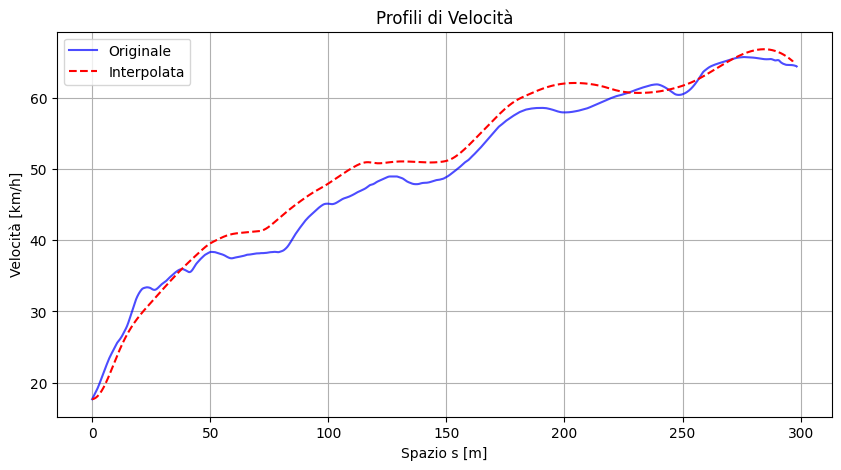

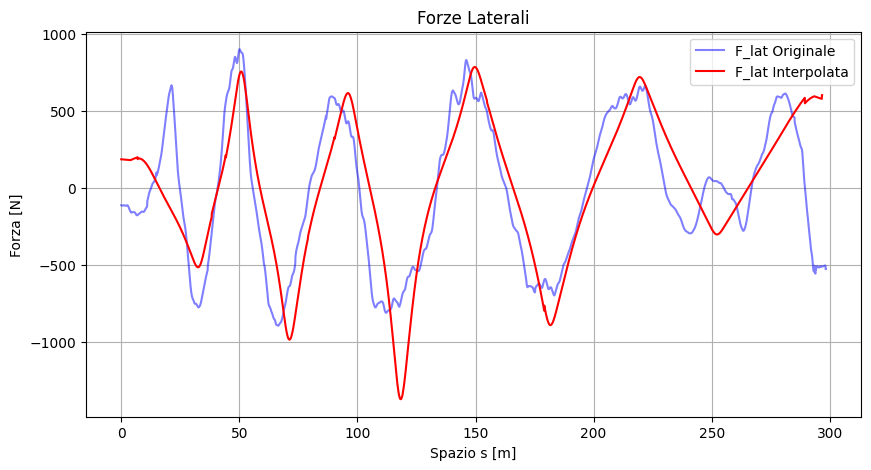

In [19]:
# Scommentare solo quando physical_model è pronto


# 
original_results = esegui_simulazione(p_com[:,0], p_com[:,1], p_com[:,2], ts_com)

# 
# NOTA: p_rec e ts_com devono avere la stessa lunghezza! 
# Se p_rec ha num_points diverso da len(ts_com), devi adattare i tempi.
generated_results = esegui_simulazione(p_rec[:,0], p_rec[:,1], p_rec[:,2], ts_com)

# 
plt.figure(figsize=(10, 5))
plt.plot(original_results['s'], original_results['v'] * 3.6, label='Originale', color='blue', alpha=0.7)
plt.plot(generated_results['s'], generated_results['v'] * 3.6, label='Interpolata', color='red', linestyle='--')
plt.title('Profili di Velocità')
plt.xlabel('Spazio s [m]')
plt.ylabel('Velocità [km/h]')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(original_results['s'], original_results['F_lat'], label='F_lat Originale', color='blue', alpha=0.5)
plt.plot(generated_results['s'], generated_results['F_lat'], label='F_lat Interpolata', color='red')
plt.title('Forze Laterali')
plt.xlabel('Spazio s [m]')
plt.ylabel('Forza [N]')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
fig = go.Figure()

# Traiettoria Reale
fig.add_trace(go.Scatter3d(
    x=p_com[:, 0], y=p_com[:, 1], z=p_com[:, 2],
    mode='lines',
    line=dict(color='blue', width=2),
    name='Traiettoria Reale (p_com)',
    hovertext=np.arange(len(p_com)),
    hovertemplate="Indice: %{hovertext}<br>X: %{x:.2f}<br>Y: %{y:.2f}<br>Z: %{z:.2f}<extra></extra>"
))

# Traiettoria Interpolata
fig.add_trace(go.Scatter3d(
    x=p_rec[:, 0], y=p_rec[:, 1], z=p_rec[:, 2],
    mode='lines',
    line=dict(color='orange', width=4, dash='dot'),
    name='Interpolazione (Rec)'
))

# Punti di Curva usati per l'interpolazione
turn_pts = p_com[TURN_INTERP_IND]
fig.add_trace(go.Scatter3d(
    x=turn_pts[:,0], y=turn_pts[:,1], z=turn_pts[:,2],
    mode='markers',
    name='Nodi (Turn points)',
    marker=dict(size=6, color='red', symbol='diamond')
))

fig.update_layout(
    title='Confronto Traiettoria 3D (Reale vs Interpolata)',
    scene=dict(
        xaxis_title='X [m]',
        yaxis_title='Y [m]',
        zaxis_title='Z [m]',
        aspectmode='data' # Mantiene le proporzioni reali dello spazio
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show(renderer='browser')